In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_excel('/kaggle/input/datasets/roronoafotsiny/customer-habits/online_retail_II.xlsx',sheet_name=0)

# EXPLORATION DES DONNEES

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [23]:
df.describe(include='O')


,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [25]:
df[df['Customer ID'].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [29]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [8]:
df["Invoice"]=df['Invoice'].astype('str')
df[df['Invoice'].str.match('^\\d{6}$') == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [5]:
df['Invoice'].str.replace('[0-9]','',regex=True).unique()

array([nan, 'C', 'A'], dtype=object)

In [12]:
df['Invoice']=df['Invoice'].astype('str')
df[df['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [17]:
df['StockCode']=df['StockCode'].astype('str')
df[(df['StockCode'].str.match('^\\d{5}$') == False) & (df['StockCode'].str.match('^\\d{5}[a-zA-Z]')==False)]['StockCode'].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', 'C3', 'SP1002', 'AMAZONFEE'], dtype=object)

# NETTOYAGE DES DONNEES

In [4]:
cleaned_df= df.copy()
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
cleaned_df['Invoice']=cleaned_df['Invoice'].astype('str')
BM=(
    cleaned_df['Invoice'].str.match('^\\d{6}$') == True
)
cleaned_df=cleaned_df[BM]

In [6]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype('str')
BM=(
    (cleaned_df['StockCode'].str.match('^\\d{5}$') == True)
    | (cleaned_df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$') == True)
    | (cleaned_df['StockCode'].str.match('^PADS$') == True)
)
cleaned_df = cleaned_df[BM]

In [7]:
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

In [7]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.000000,406337,406337.000000,406337.000000
mean,13.619099,2010-07-01 10:11:06.543288320,2.991462,15373.632992
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000659,NaN,4.285876,1677.365907


In [8]:
len(cleaned_df)/len(df)

0.7732962103752705

In [9]:
len(cleaned_df[cleaned_df['Price'] == 0])

28

In [8]:
cleaned_df=cleaned_df[cleaned_df['Price'] > 0]

In [9]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.000000,406309,406309.000000,406309.000000
mean,13.617924,2010-07-01 10:14:25.869572352,2.991668,15373.722268
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,96.998833,NaN,4.285951,1677.329470


<H1> Future Engineering

In [9]:
cleaned_df['SalesLineTotal'] = cleaned_df['Price'] * cleaned_df['Quantity']
cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [10]:
aggregated_df = cleaned_df.groupby(by='Customer ID',as_index=False)\
    .agg(
        MonetaryValue = ('SalesLineTotal',"sum"),
        Frequency=('Invoice','nunique'),
        LastInvoiceDate=('InvoiceDate','max')
    )
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [11]:
max_invoice_date = aggregated_df['LastInvoiceDate'].max()
aggregated_df['Recency']=(max_invoice_date - aggregated_df['LastInvoiceDate']).dt.days
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


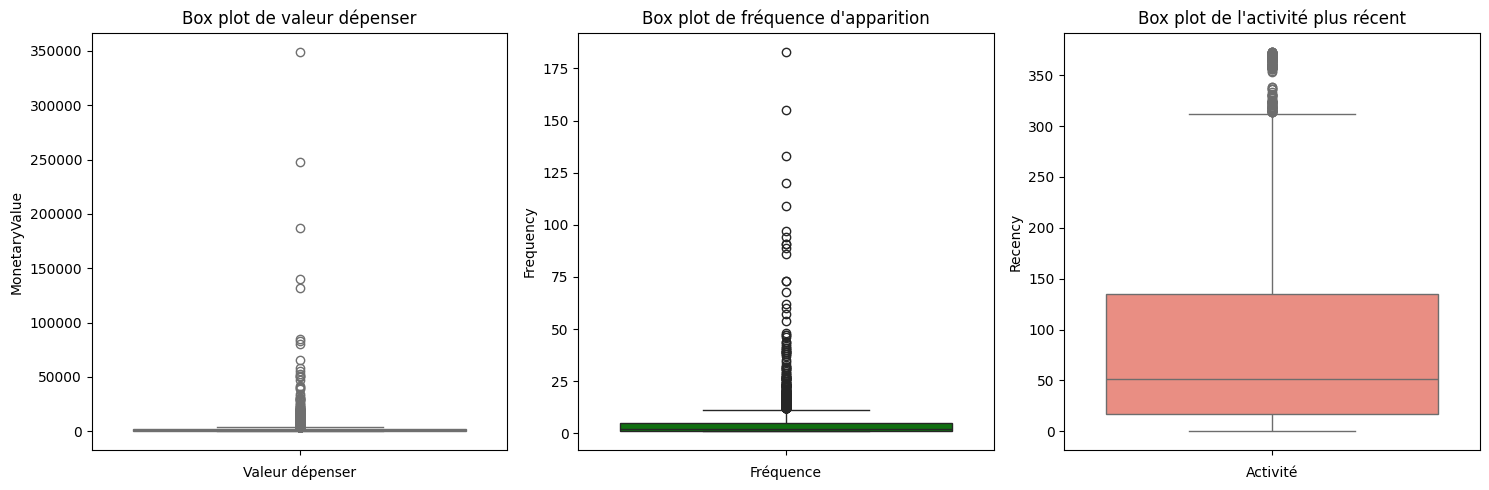

In [11]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(data=aggregated_df['MonetaryValue'],color='skyblue')
plt.title('Box plot de valeur dépenser')
plt.xlabel('Valeur dépenser')

plt.subplot(1,3,2)
sns.boxplot(data=aggregated_df['Frequency'],color='green')
plt.title('Box plot de fréquence d\'apparition')
plt.xlabel('Fréquence')

plt.subplot(1,3,3)
sns.boxplot(data=aggregated_df['Recency'],color='salmon')
plt.title('Box plot de l\'activité plus récent')
plt.xlabel('Activité')

plt.tight_layout()
plt.show()

In [12]:
M_Q1= aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3= aggregated_df['MonetaryValue'].quantile(0.75)
M_EIQ= M_Q3 - M_Q1

monetary_outliers_df = aggregated_df[
    (aggregated_df['MonetaryValue'] > (M_Q3 + 1.5 * M_EIQ)) | 
    (aggregated_df['MonetaryValue'] < (M_Q1 - 1.5 * M_EIQ))
].copy()
monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.000000,423.000000,423.000000,423,423.000000
mean,15103.040189,12188.101740,17.167849,2010-11-09 12:26:02.978723328,30.035461
min,12357.000000,3802.040000,1.000000,2009-12-10 18:03:00,0.000000
25%,13622.000000,4605.940000,8.000000,2010-11-08 13:17:30,3.000000
50%,14961.000000,6191.320000,12.000000,2010-11-26 12:19:00,13.000000
75%,16692.000000,10273.235000,18.000000,2010-12-06 10:34:30,31.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1728.661406,25830.851045,19.729755,NaN,51.541004


In [13]:
F_Q1= aggregated_df['Frequency'].quantile(0.25)
F_Q3= aggregated_df['Frequency'].quantile(0.75)
F_EIQ= F_Q3 - F_Q1

frequency_outliers_df = aggregated_df[
    (aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_EIQ)) | 
    (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_EIQ))
].copy()
frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14409.714932,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.390000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.560500,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31381.736785,21.932937,NaN,26.589117


In [14]:
non_outliers_df= aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index) & (~aggregated_df.index.isin(frequency_outliers_df.index)))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.000000,3809.000000,3809.000000,3809,3809.000000
mean,15376.482804,885.502197,2.863481,2010-09-03 11:16:46.516146176,97.082174
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,22.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,58.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.199806,817.672283,2.243748,NaN,98.111495


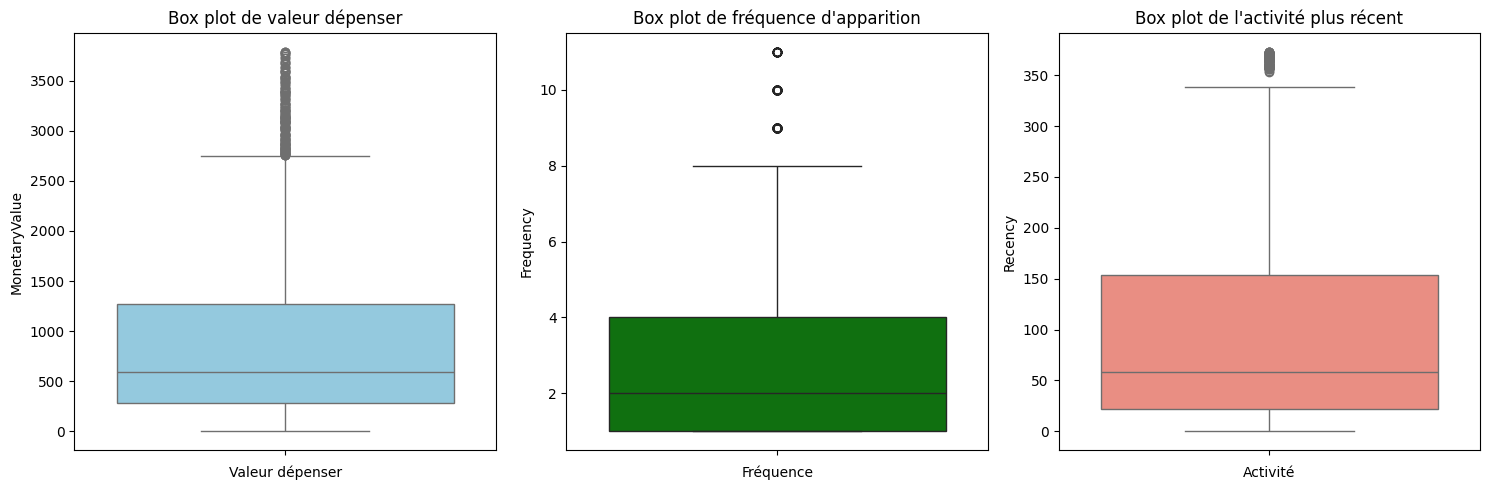

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(data=non_outliers_df['MonetaryValue'],color='skyblue')
plt.title('Box plot de valeur dépenser')
plt.xlabel('Valeur dépenser')

plt.subplot(1,3,2)
sns.boxplot(data=non_outliers_df['Frequency'],color='green')
plt.title('Box plot de fréquence d\'apparition')
plt.xlabel('Fréquence')

plt.subplot(1,3,3)
sns.boxplot(data=non_outliers_df['Recency'],color='salmon')
plt.title('Box plot de l\'activité plus récent')
plt.xlabel('Activité')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

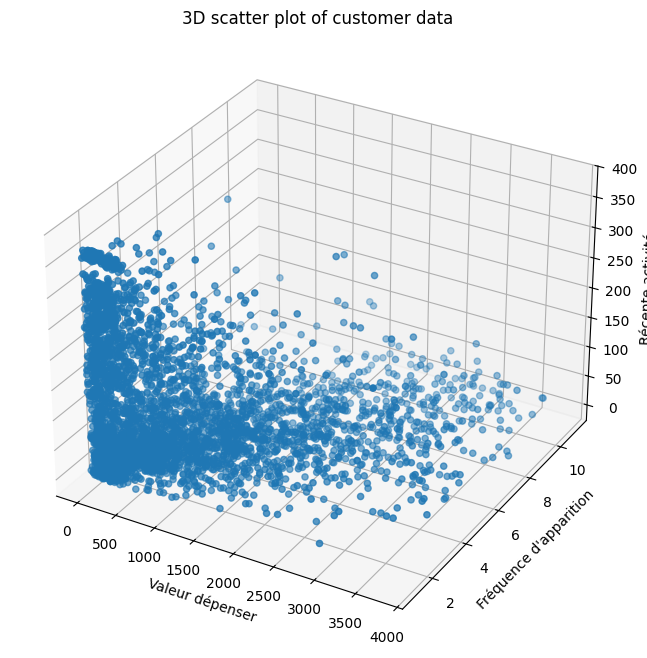

In [14]:
fig = plt.figure(figsize=(8,8))
axe= fig.add_subplot(projection='3d')
scatter =axe.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'])

axe.set_xlabel('Valeur dépenser')
axe.set_ylabel('Fréquence d\'apparition')
axe.set_zlabel('Récente activité')

axe.set_title('3D scatter plot of customer data')

plt.show

<H1>NORMALISATION DES DONNEES</H1>

In [15]:
scaler = StandardScaler()
scaled_data=scaler.fit_transform(non_outliers_df[['MonetaryValue','Frequency','Recency']])
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [16]:
scaled_df = pd.DataFrame(scaled_data,index=non_outliers_df.index, columns = ['MonetaryValue','Frequency','Recency'])
scaled_df

,MonetaryValue,Frequency,Recency
0,-0.875945,-0.384889,0.682149
1,0.535514,-0.384889,-0.969251
2,-0.812586,-0.830631,-0.245489
3,1.633678,-0.384889,-0.561498
4,-0.715016,-0.830631,-0.887700
...,...,...,...
4280,-0.298120,1.398076,-0.816344
4281,-0.579553,-0.830631,-0.316846
4282,-0.621972,-0.830631,2.017539
4283,0.441467,-0.384889,0.141876


<function matplotlib.pyplot.show(close=None, block=None)>

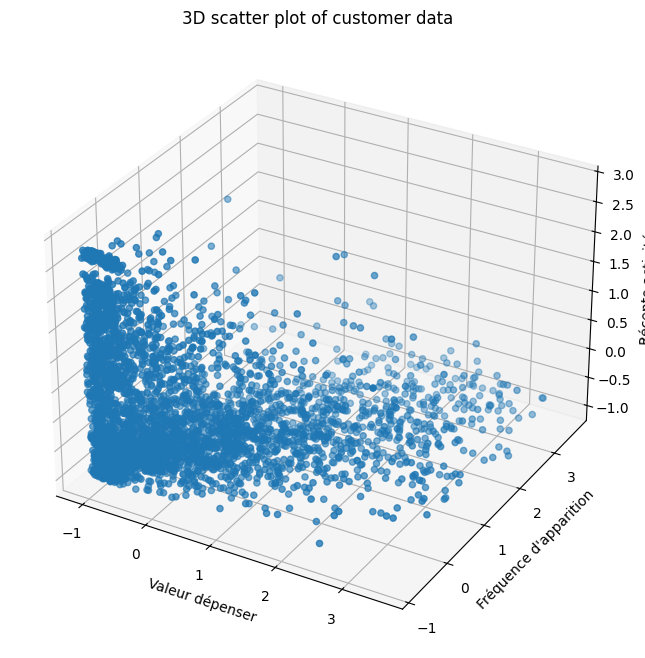

In [17]:
fig = plt.figure(figsize=(8,8))
axe= fig.add_subplot(projection='3d')
scatter =axe.scatter(scaled_df['MonetaryValue'], scaled_df['Frequency'], scaled_df['Recency'])

axe.set_xlabel('Valeur dépenser')
axe.set_ylabel('Fréquence d\'apparition')
axe.set_zlabel('Récente activité')

axe.set_title('3D scatter plot of customer data')

plt.show

<H1>KMEAN CLUSTERING</H1>

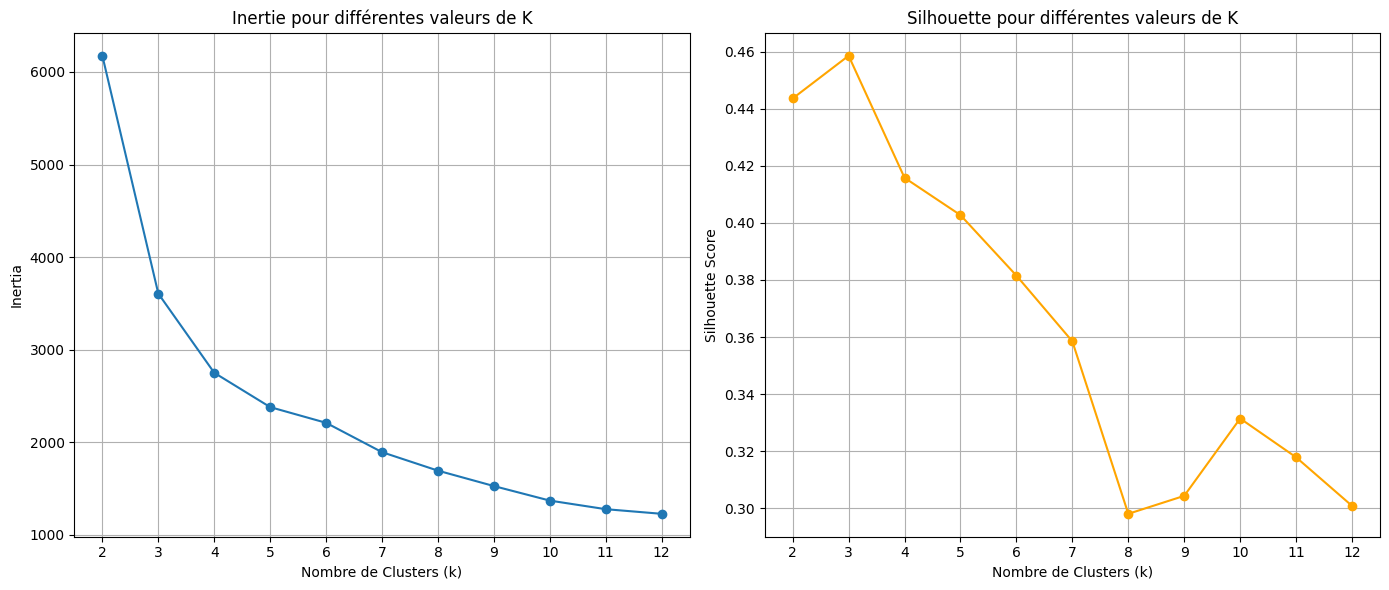

In [18]:
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(scaled_df)
    sil_score = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('Inertie pour différentes valeurs de K')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette pour différentes valeurs de K')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
kmeans= KMeans(n_clusters=4, random_state=42, max_iter=1000)
cluster_labels = kmeans.fit_predict(scaled_df)
cluster_labels

array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

In [20]:
import joblib
import json

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [21]:
non_outliers_df['Cluster']= cluster_labels
non_outliers_df

/tmp/ipykernel_55/3470492757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster']= cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.0,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.0,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111,0


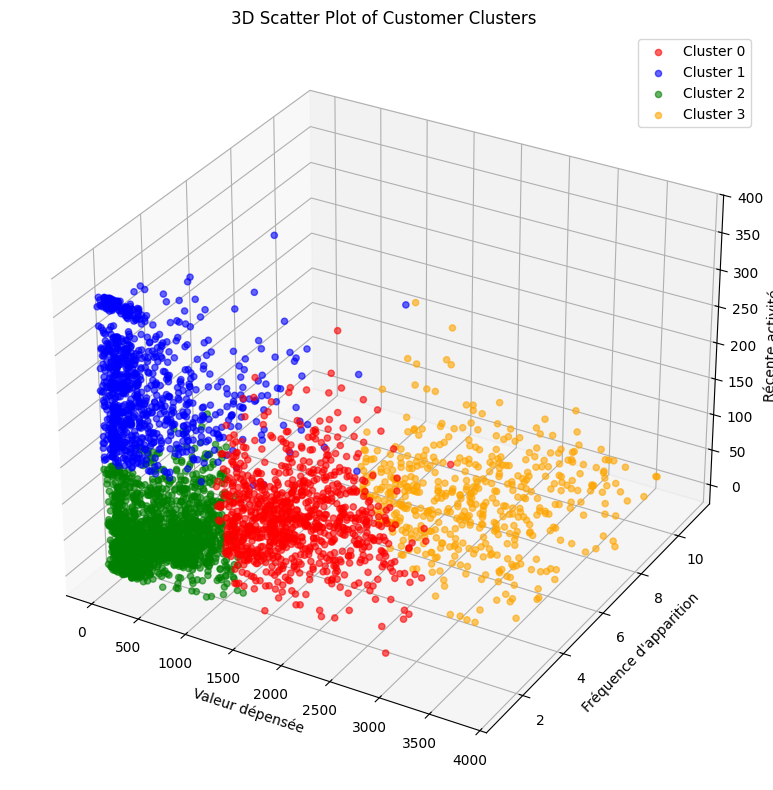

In [22]:
colors = ['red', 'blue', 'green', 'orange']
labels = [f'Cluster {i}' for i in range(4)]
fig = plt.figure(figsize=(8, 8))
axe = fig.add_subplot(projection='3d')
for i in range(4):
    mask = non_outliers_df['Cluster'] == i
    axe.scatter(
        non_outliers_df.loc[mask, 'MonetaryValue'],
        non_outliers_df.loc[mask, 'Frequency'],
        non_outliers_df.loc[mask, 'Recency'],
        c=colors[i],
        label=labels[i],
        alpha=0.6
    )
axe.set_xlabel('Valeur dépensée')
axe.set_ylabel("Fréquence d'apparition")
axe.set_zlabel('Récente activité')
axe.set_title('3D Scatter Plot of Customer Clusters')
axe.legend()
plt.tight_layout()
plt.show()

## Analyse des Clusters Clients

### Cluster 0 (Bleu) : "Fidéliser"
**Justification :** Ce cluster représente des clients à haute valeur qui achètent régulièrement,
bien que pas toujours très récemment. L'accent doit être mis sur la fidélisation afin de
maintenir leur loyauté et leur niveau de dépenses.

**Action :** Mettre en place des programmes de fidélité, des offres personnalisées et un
engagement régulier pour s'assurer qu'ils restent actifs.

---

### Cluster 1 (Orange) : "Réengager"
**Justification :** Ce groupe comprend des acheteurs peu fréquents et à faible valeur qui
n'ont pas effectué d'achat récemment. L'accent doit être mis sur le réengagement afin de
les ramener à un comportement d'achat actif.

**Action :** Utiliser des campagnes marketing ciblées, des remises spéciales ou des rappels
pour les inciter à revenir et à acheter à nouveau.

---

### Cluster 2 (Vert) : "Cultiver"
**Justification :** Ce cluster représente les clients les moins actifs et à plus faible valeur,
mais qui ont effectué des achats récents. Ces clients peuvent être nouveaux ou avoir besoin
d'un accompagnement pour augmenter leur engagement et leurs dépenses.

**Action :** Se concentrer sur la construction de relations, offrir un excellent service client
et proposer des incentives pour encourager des achats plus fréquents.

---

### Cluster 3 (Rouge) : "Récompenser"
**Justification :** Ce cluster comprend des acheteurs à haute valeur et très fréquents, dont
beaucoup sont encore actifs.Il faut récompenser leur
fidélité, c'est essentiel pour maintenir leur engagement.

**Action :** Mettre en place un programme de fidélité robuste, proposer des offres exclusives
et reconnaître leur loyauté pour les maintenir engagés et satisfaits.

---


<H1>Considération Outliers</H1>

In [23]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


## Analyse des Clusters Outliers

### Cluster -1 (Outliers Monétaires) : "Chouchouter"
**Caractéristiques :** Grands dépensiers mais pas nécessairement des acheteurs fréquents.
Leurs achats sont importants mais peu fréquents.

**Stratégie potentielle :** Se concentrer sur le maintien de leur fidélité grâce à des offres
personnalisées ou des services premium adaptés à leur forte capacité de dépense.

---

### Cluster -2 (Outliers de Fréquence) : "Upseller"
**Caractéristiques :** Acheteurs fréquents qui dépensent moins par achat. Ces clients sont
régulièrement engagés mais pourraient bénéficier d'opportunités de montée en gamme.

**Stratégie potentielle :** Mettre en place des programmes de fidélité ou des offres groupées
pour encourager des dépenses plus élevées par visite, compte tenu de leur engagement fréquent.

---

### Cluster -3 (Outliers Monétaires & Fréquence) : "Enchanter"
**Caractéristiques :** Les outliers les plus précieux, avec des dépenses extrêmes et des achats
fréquents. Ce sont les clients de premier rang qui nécessitent une attention
particulière.

**Stratégie potentielle :** Développer des programmes VIP ou des offres exclusives pour
maintenir leur fidélité et encourager un engagement continu.

---

## Récapitulatif des Clusters Outliers

| Cluster | Type d'Outlier                  | Nom        |
|---------|---------------------------------|------------|
| -1      | Outliers Monétaires             | Chouchouter|
| -2      | Outliers de Fréquence           | Upseller   |
| -3      | Outliers Monétaires & Fréquence | Enchanter  |

In [25]:
cluster_labels = {
    0: "FIDÉLISER",
    1: "RÉENGAGER",
    2: "CULTIVER",
    3: "RÉCOMPENSER",
    -1: "CHOUCHOUTER",
    -2: "UPSELLER",
    -3: "ENCHANTER"
}

In [26]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


In [27]:

full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1,RÉENGAGER
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0,FIDÉLISER
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2,CULTIVER
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0,FIDÉLISER
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2,CULTIVER
...,...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3,ENCHANTER
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3,ENCHANTER
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3,ENCHANTER
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3,ENCHANTER


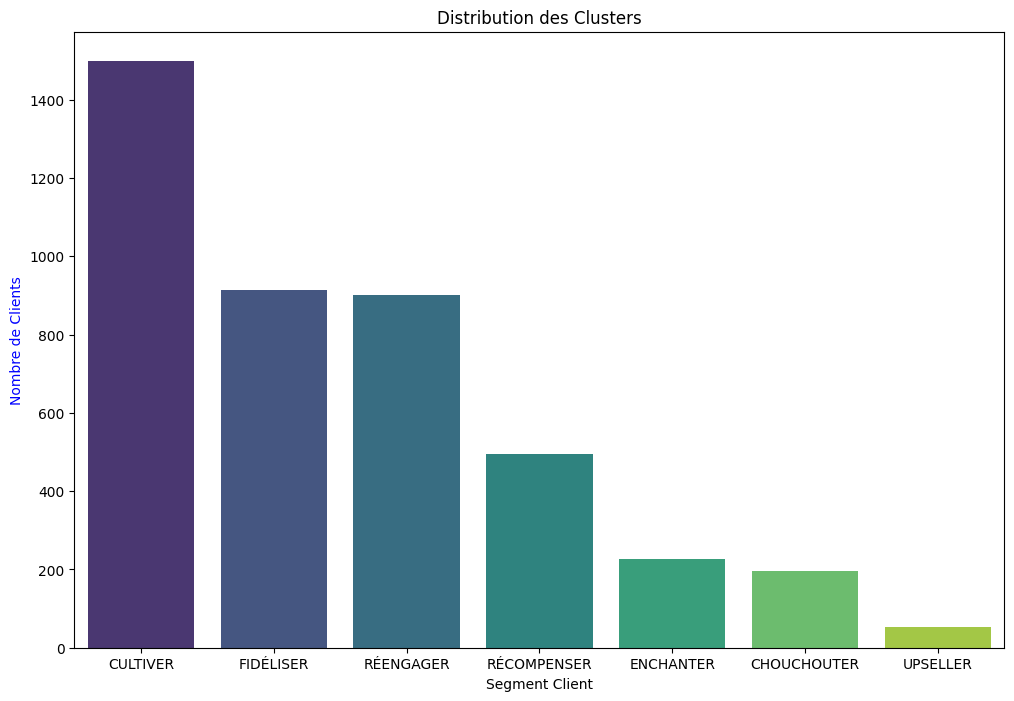

In [28]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()

fig, ax1 = plt.subplots(figsize=(12, 8))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Nombre de Clients', color='b')
ax1.set_xlabel('Segment Client')
ax1.set_title('Distribution des Clusters')
plt.show()